# Analyse du Sweep Fairness Lambda

Comparaison des modèles entraînés avec différentes valeurs de `fairness_lambda`.

**Prérequis** : avoir récupéré les résultats du sweep depuis le cluster :
```bash
scp -r ivars-25@gpu-gw.enst.fr:~/Data-Challenge-Telecom-Paris-Face-Occlusion/data/submissions/ data/
```

In [8]:
import os
import sys
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "__vsc_ipynb_file__" in dir():
    PROJECT_ROOT = os.path.dirname(os.path.dirname(os.path.abspath(__vsc_ipynb_file__)))
else:
    PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
print(f"Working directory: {os.getcwd()}")

%matplotlib inline

Working directory: /home/leo/Data_Challenge_Telecom/Data-Challenge-Telecom-Paris-Face-Occlusion


## 1. Charger tous les runs du sweep

In [ ]:
# Trouver le dossier sweep le plus récent
sweep_dirs = sorted(glob.glob("data/submissions/checkpoints/sweep_*"))
if not sweep_dirs:
    raise FileNotFoundError("Aucun dossier sweep trouvé. As-tu récupéré les résultats du cluster ?")

SWEEP_DIR = sweep_dirs[-1]  # le plus récent
print(f"Sweep dir: {SWEEP_DIR}")

# Charger les historiques
runs = []
for run_dir in sorted(glob.glob(os.path.join(SWEEP_DIR, "lambda_*"))):
    history_path = os.path.join(run_dir, "history.json")
    if not os.path.isfile(history_path):
        print(f"  SKIP {run_dir} (pas de history.json)")
        continue
    with open(history_path) as f:
        h = json.load(f)
    lam = float(os.path.basename(run_dir).replace("lambda_", ""))
    best_idx = int(np.argmin(h["val_score"]))
    runs.append({
        "lambda": lam,
        "dir": run_dir,
        "history": h,
        "best_epoch": h["epoch"][best_idx],
        "best_score": h["val_score"][best_idx],
        "best_err_f": h["err_f"][best_idx],
        "best_err_m": h["err_m"][best_idx],
        "best_gap": abs(h["err_f"][best_idx] - h["err_m"][best_idx]),
    })

df_runs = pd.DataFrame([{k: v for k, v in r.items() if k != "history"} for r in runs])
df_runs = df_runs.sort_values("lambda").reset_index(drop=True)
print(f"\n{len(runs)} runs chargés")
df_runs

Sweep dir: data/submissions/checkpoints/sweep_20260604_143401

6 runs chargés


,lambda,dir,best_epoch,best_score,best_err_f,best_err_m,best_gap
0,0.00,data/submissions/checkpoints/sweep_20260604_14...,21,0.001187,0.000681,0.001019,0.000338
1,0.25,data/submissions/checkpoints/sweep_20260604_14...,22,0.001197,0.000688,0.001028,0.000339
2,0.50,data/submissions/checkpoints/sweep_20260604_14...,20,0.001240,0.000711,0.001064,0.000353
3,1.00,data/submissions/checkpoints/sweep_20260604_14...,22,0.001208,0.000788,0.001068,0.000280
4,2.00,data/submissions/checkpoints/sweep_20260604_14...,30,0.001312,0.000907,0.001177,0.000269
5,5.00,data/submissions/checkpoints/sweep_20260604_14...,25,0.001340,0.001292,0.001324,0.000032


## 2. Tableau récapitulatif

In [10]:
best_run = df_runs.loc[df_runs["best_score"].idxmin()]

print(f"{'lambda':>8} {'score':>10} {'err_f':>10} {'err_m':>10} {'gap':>10} {'epoch':>6}")
print("-" * 58)
for _, row in df_runs.iterrows():
    marker = " <-- BEST" if row["lambda"] == best_run["lambda"] else ""
    print(f"{row['lambda']:>8.2f} {row['best_score']:>10.6f} {row['best_err_f']:>10.6f} "
          f"{row['best_err_m']:>10.6f} {row['best_gap']:>10.6f} {int(row['best_epoch']):>6}{marker}")

print(f"\nMeilleur lambda = {best_run['lambda']:.2f} (score = {best_run['best_score']:.6f})")

  lambda      score      err_f      err_m        gap  epoch
----------------------------------------------------------
    0.00   0.001187   0.000681   0.001019   0.000338     21 <-- BEST
    0.25   0.001197   0.000688   0.001028   0.000339     22
    0.50   0.001240   0.000711   0.001064   0.000353     20
    1.00   0.001208   0.000788   0.001068   0.000280     22
    2.00   0.001312   0.000907   0.001177   0.000269     30
    5.00   0.001340   0.001292   0.001324   0.000032     25

Meilleur lambda = 0.00 (score = 0.001187)


## 3. Score vs Lambda

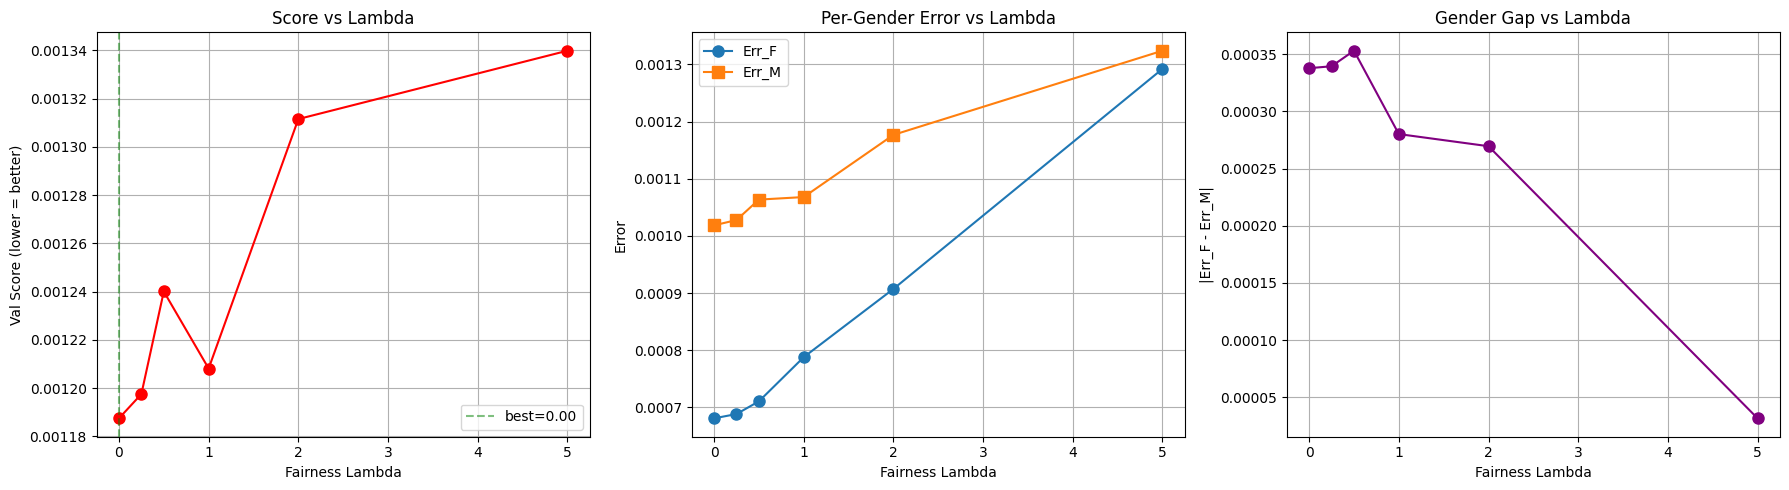

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Score vs lambda
axes[0].plot(df_runs["lambda"], df_runs["best_score"], "o-", color="red", markersize=8)
axes[0].axvline(best_run["lambda"], color="green", linestyle="--", alpha=0.5, label=f"best={best_run['lambda']:.2f}")
axes[0].set_xlabel("Fairness Lambda")
axes[0].set_ylabel("Val Score (lower = better)")
axes[0].set_title("Score vs Lambda")
axes[0].legend()
axes[0].grid(True)

# Err_F / Err_M vs lambda
axes[1].plot(df_runs["lambda"], df_runs["best_err_f"], "o-", label="Err_F", markersize=8)
axes[1].plot(df_runs["lambda"], df_runs["best_err_m"], "s-", label="Err_M", markersize=8)
axes[1].set_xlabel("Fairness Lambda")
axes[1].set_ylabel("Error")
axes[1].set_title("Per-Gender Error vs Lambda")
axes[1].legend()
axes[1].grid(True)

# Gap vs lambda
axes[2].plot(df_runs["lambda"], df_runs["best_gap"], "o-", color="purple", markersize=8)
axes[2].set_xlabel("Fairness Lambda")
axes[2].set_ylabel("|Err_F - Err_M|")
axes[2].set_title("Gender Gap vs Lambda")
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 4. Courbes d'entraînement comparées

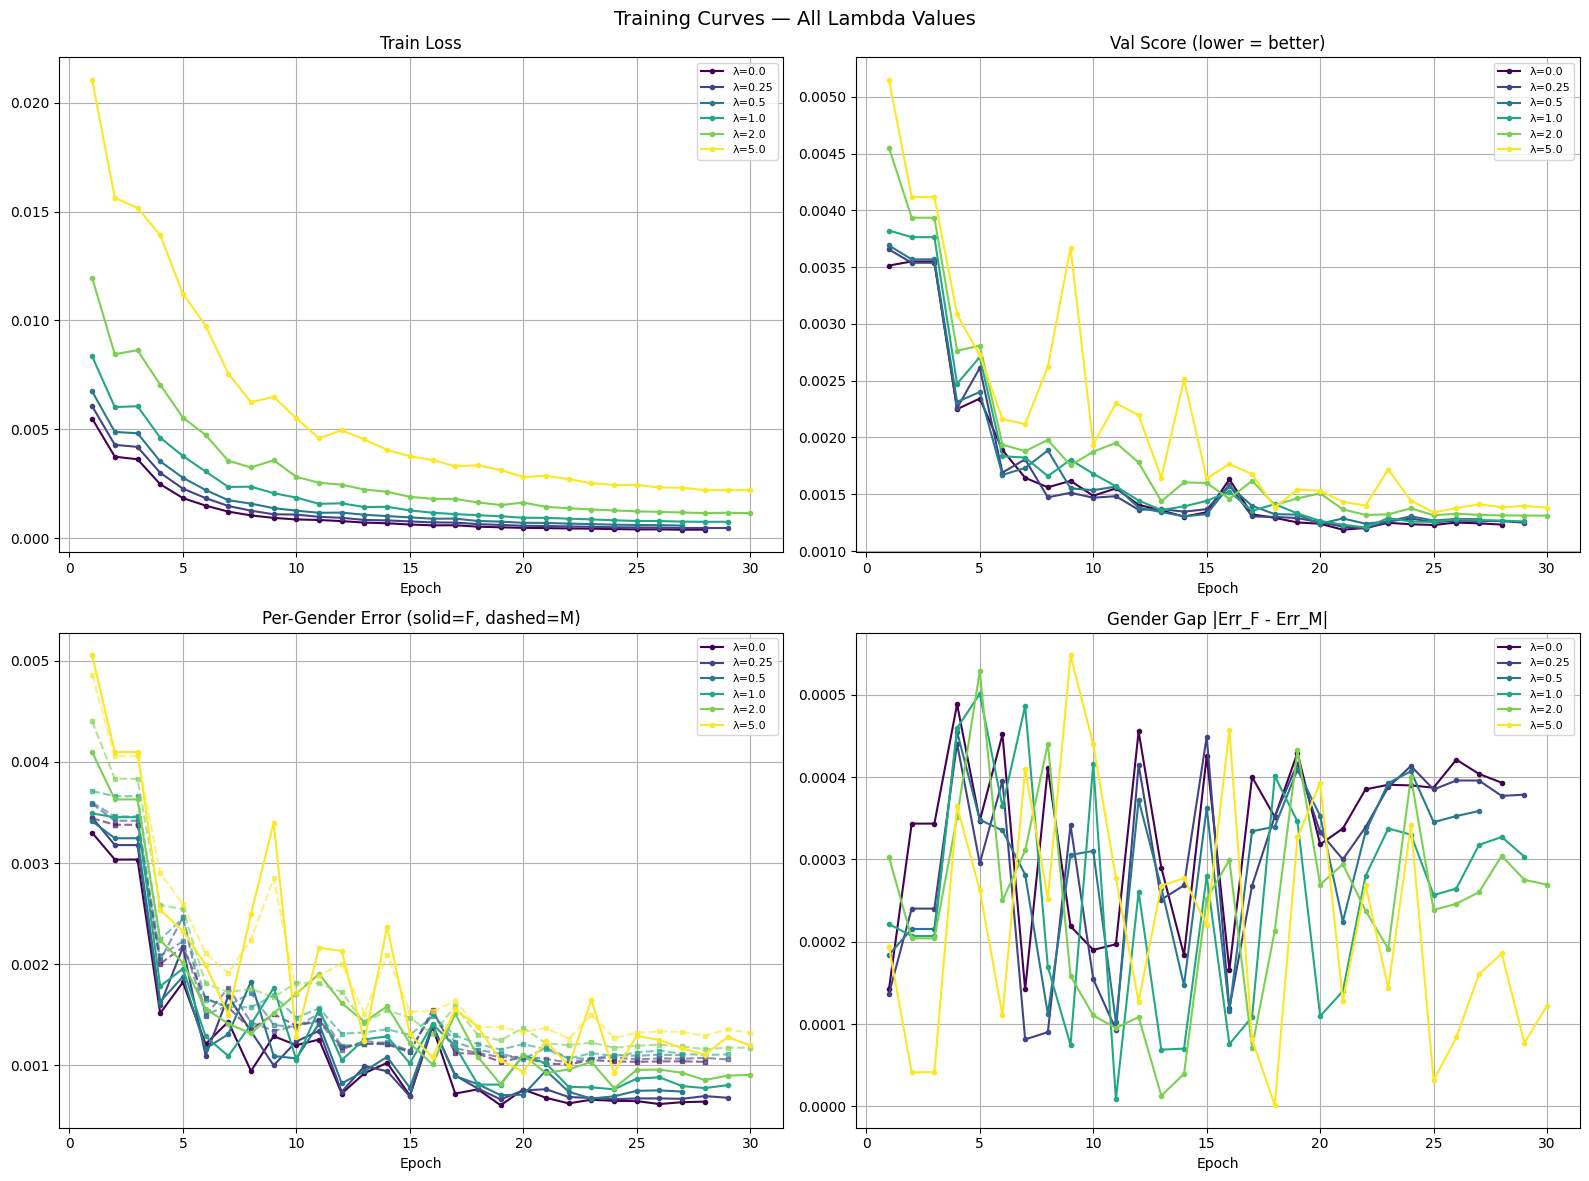

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
cmap = plt.cm.viridis(np.linspace(0, 1, len(runs)))

for i, run in enumerate(runs):
    h = run["history"]
    label = f"λ={run['lambda']}"
    c = cmap[i]

    axes[0, 0].plot(h["epoch"], h["train_loss"], "o-", color=c, label=label, markersize=3)
    axes[0, 1].plot(h["epoch"], h["val_score"], "o-", color=c, label=label, markersize=3)
    axes[1, 0].plot(h["epoch"], h["err_f"], "o-", color=c, label=label, markersize=3)
    axes[1, 0].plot(h["epoch"], h["err_m"], "s--", color=c, markersize=3, alpha=0.6)
    gap = [abs(f - m) for f, m in zip(h["err_f"], h["err_m"])]
    axes[1, 1].plot(h["epoch"], gap, "o-", color=c, label=label, markersize=3)

axes[0, 0].set_title("Train Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True)

axes[0, 1].set_title("Val Score (lower = better)")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True)

axes[1, 0].set_title("Per-Gender Error (solid=F, dashed=M)")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True)

axes[1, 1].set_title("Gender Gap |Err_F - Err_M|")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True)

plt.suptitle("Training Curves — All Lambda Values", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Trade-off : Accuracy vs Fairness

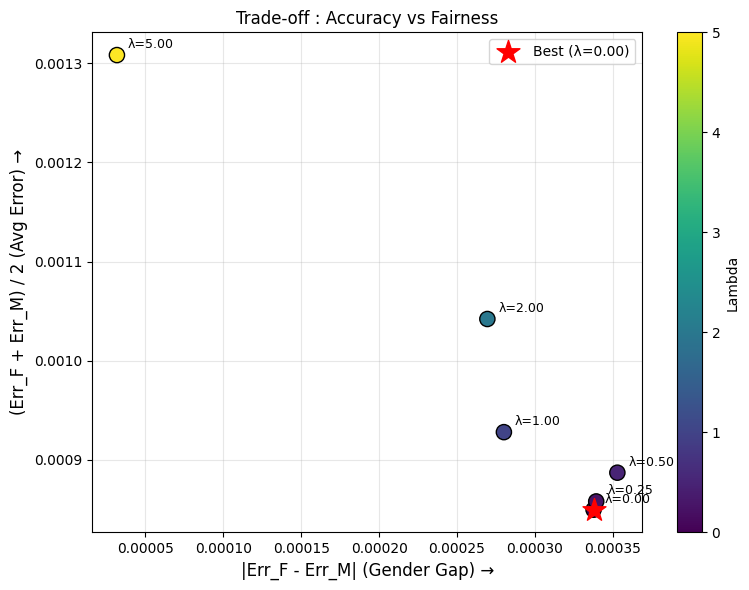

In [13]:
# Moyenne des erreurs = proxy de l'accuracy, gap = fairness
df_runs["avg_err"] = (df_runs["best_err_f"] + df_runs["best_err_m"]) / 2

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(df_runs["best_gap"], df_runs["avg_err"],
                     c=df_runs["lambda"], cmap="viridis", s=120, edgecolors="black", zorder=5)

for _, row in df_runs.iterrows():
    ax.annotate(f"λ={row['lambda']:.2f}",
                (row["best_gap"], row["avg_err"]),
                textcoords="offset points", xytext=(8, 5), fontsize=9)

# Highlight best score
ax.scatter(best_run["best_gap"], (best_run["best_err_f"] + best_run["best_err_m"]) / 2,
           marker="*", s=300, color="red", zorder=10, label=f"Best (λ={best_run['lambda']:.2f})")

ax.set_xlabel("|Err_F - Err_M| (Gender Gap) →", fontsize=12)
ax.set_ylabel("(Err_F + Err_M) / 2 (Avg Error) →", fontsize=12)
ax.set_title("Trade-off : Accuracy vs Fairness")
ax.legend()
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, label="Lambda")
plt.tight_layout()
plt.show()